In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')

In [2]:
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


i cann see that this data set has info about total bill, tip, sex, smoker, day, time, size


In [3]:
df.shape

(244, 7)

this dataframe has 244 rows and 7 columns which means there are 244 bills in total


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


there are no NaN cells in this data set

In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


max tip is 10 while min tip is 1

In [6]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

there is no missing data

In [9]:
len(df[df['time'] == 'Dinner'])

176

In [10]:
len(df[df['total_bill'] > 30])

32

In [12]:
len(df[(df['sex'] == 'Female') & (df['smoker'] == 'Yes')])

33

In [15]:
df['tip_percent'] = (df['tip'] / df['total_bill'] * 100).round(2)

In [19]:
df['bill_per_person'] = (df['total_bill'] / df['size']).round(2)

In [21]:
df['is_generous'] = df['tip_percent'] > 20

In [22]:
df

,total_bill,tip,sex,smoker,day,time,size,tip_percent,bill_per_person,is_generous
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94,8.49,False
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05,3.45,False
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66,7.00,False
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98,11.84,False
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68,6.15,False
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.39,9.68,True
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.36,13.59,False
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.82,11.34,False
242,17.82,1.75,Male,No,Sat,Dinner,2,9.82,8.91,False


In [26]:
df['tip'].mean().round(2)

np.float64(3.0)

average percentage of tip in the data set is 3.0

In [31]:
df.groupby('sex')['tip'].mean()

/var/folders/vr/dr1s8fb178gfh3rh2tzhxjth0000gp/T/ipykernel_29057/3407121299.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['tip'].mean()


sex
Male      3.089618
Female    2.833448
Name: tip, dtype: float64

males are more generous

In [57]:
df.groupby('day')['tip'].mean()

/var/folders/vr/dr1s8fb178gfh3rh2tzhxjth0000gp/T/ipykernel_29057/4148581069.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['tip'].mean()


day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

In [39]:
df.groupby('smoker')['tip_percent'].mean()

/var/folders/vr/dr1s8fb178gfh3rh2tzhxjth0000gp/T/ipykernel_29057/1555110191.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('smoker')['tip_percent'].mean()


smoker
Yes    16.319140
No     15.932318
Name: tip_percent, dtype: float64

In [49]:
df.sort_values('tip_percent', ascending=False)

,total_bill,tip,sex,smoker,day,time,size,tip_percent,bill_per_person,is_generous
172,7.25,5.15,Male,Yes,Sun,Dinner,2,71.03,3.62,True
178,9.60,4.00,Female,Yes,Sun,Dinner,2,41.67,4.80,True
67,3.07,1.00,Female,Yes,Sat,Dinner,1,32.57,3.07,True
232,11.61,3.39,Male,No,Sat,Dinner,2,29.20,5.80,True
183,23.17,6.50,Male,Yes,Sun,Dinner,4,28.05,5.79,True
...,...,...,...,...,...,...,...,...,...,...
187,30.46,2.00,Male,Yes,Sun,Dinner,5,6.57,6.09,False
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94,8.49,False
57,26.41,1.50,Female,No,Sat,Dinner,2,5.68,13.20,False
102,44.30,2.50,Female,Yes,Sat,Dinner,3,5.64,14.77,False


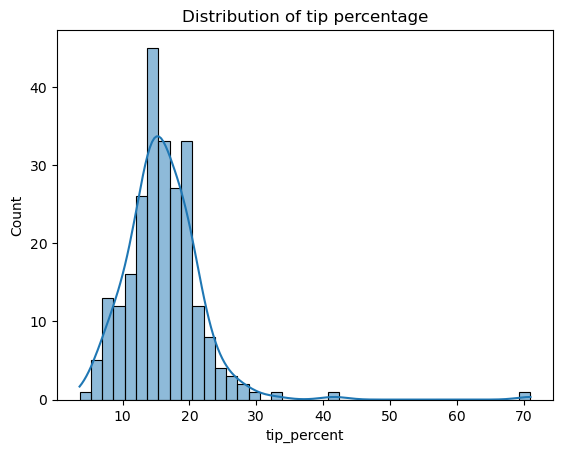

In [52]:
sns.histplot(df['tip_percent'], bins=40, kde=True)
plt.title('Distribution of tip percentage')
plt.show()

not symmetrical, from this graph we can see that clients give around 15% tip from their total bill

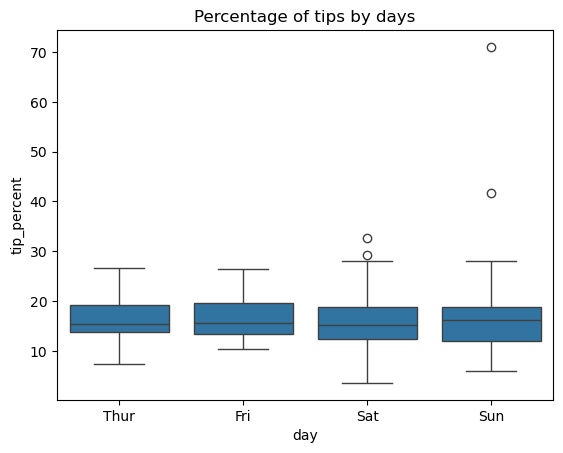

In [55]:
sns.boxplot(data=df, x='day', y='tip_percent')
plt.title("Percentage of tips by days")
plt.show()

on sundays the tip percent is far higher than in other days of the week

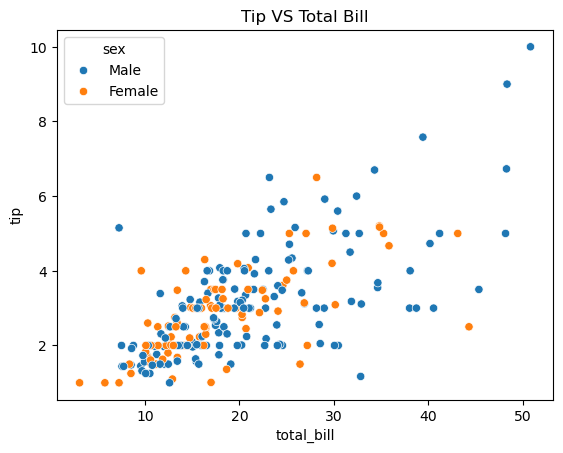

In [56]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.title('Tip VS Total Bill')
plt.show()

the higher the total bill the higher is the tip, males tend to has higher total bill

# Conclusions
1. The clients tend to give around 15% tip from their total bill
2. The tip at sundays is higher than in other days with 3.0 while next highest tip day is saturday with 2.9 meaning that tip is usually bigger on weekends
3. The higher the total bill the higher is the tip( 10 tip for 50 total bill; 2 tip for 10 total bill), males tend to has higher total bills (because its usual fro males to pay a check)